
# A finance tool: the geometric Brownian motion

**Options** in finance play a crucial role in several economical processes and it is important to study them in order to understand better the market. Roughly speaking, an option is a contract that gives the buyer the right—but not the obligation—to buy or sell an asset at a set price before or on a specific date.

The **Black–Scholes model** is a useful tool to know how an option will behave under certain conditions (e.g. it is an European option, there is no arbitrage, there are no friction in the market such as taxes etc...).

The dynamic of the price is described by the **Geometric Browinan Motion**, which allows us to preserve the positivity of the price of the stocks.



## 1. What is Geometric Brownian Motion (GBM)?

A **stochastic differential equation (SDE)** for GBM is:
\begin{equation}
dS_t = \mu S_t\,dt + \sigma S_t\,dW_t,
\end{equation}
where:
- $S_t$ is the process (e.g., the stock price) at time $t$.
- $\mu$ is the **drift** (i.e. average growth rate).
- $\sigma$ is the **volatility**.
- $W_t$ is a **standard Brownian motion**.




## 2. The Euler–Maruyama (Euler) Method

For small time step $\Delta t$, we approximate the SDE increment by
\begin{equation}
S_{t+\Delta t} \approx S_t + \mu S_t \,\Delta t + \sigma S_t \,\Delta W,
\end{equation}
with $\Delta W \sim \mathcal{N}(0, \Delta t)$. The idea is pretty similar to the standard ODE case

We divide out interval $[0,T]$ in $N$ steps:
1. Set $S_0$ (initial value).
2. For each step $n=0,\dots,N-1$:
   - Draw $Z_n \sim \mathcal{N}(0,1)$.
   - Set $\Delta W_n = \sqrt{\Delta t}\,Z_n$.
   - Update $S_{n+1} = S_n + \mu S_n \Delta t + \sigma S_n \Delta W_n$.

The smaller is the $\Delta t$ and higher is the accuracy of the solution, even though there will be an higher computational cost.


We import **NumPY** for mathematical operation and **matplotlib** for visualization. Let us introduce also some parameters to deliver simulations.

In [5]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

S0 = 100.0   # initial level
mu = 0.08    # drift 
sigma = 0.2  # volatility 
T = 1.0      # total time horizon (e.g., 1 year)
N = 252      # number of time steps (e.g., trading days in a year)


We'll write a small function to return the **entire path** $(S_0,\dots,S_N)$.

In [6]:
def euler_maruyama_gbm(S0, mu, sigma, T, N):
    dt = T / N
    t = np.linspace(0, T, N + 1)
    S = np.empty(N + 1)
    S[0] = S0
    Z = np.random.randn(N)
    for n in range(N):
        dW = np.sqrt(dt) * Z[n]
        S[n + 1] = S[n] + mu * S[n] * dt + sigma * S[n] * dW
    return t, S

Let's generate a single geometric brownian motion and plot it.


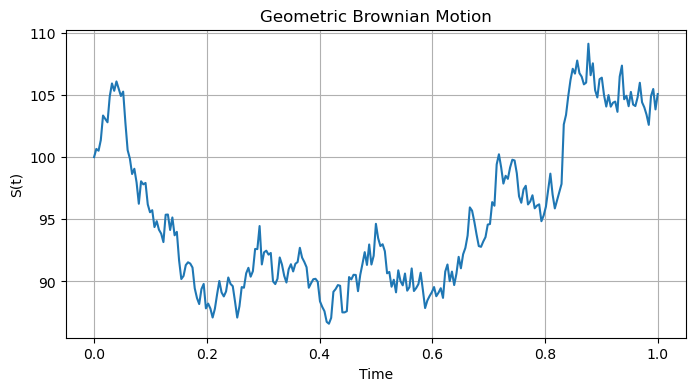

In [7]:
t, S = euler_maruyama_gbm(S0, mu, sigma, T, N)
plt.figure(figsize=(8, 4))
plt.plot(t, S)
plt.xlabel('Time')
plt.ylabel('S(t)')
plt.title('Geometric Brownian Motion')
plt.grid(True)
plt.show()

Now we'll simulate multiple paths to see variability. This is useful for understanding distributions and for estimating expected values and it is the base to apply the so called **Monte Carlo Methods**.

These methods are useful to estimate solutions of many different models in physics and economy, especially the one related to **Feymann-Kac forumula**-


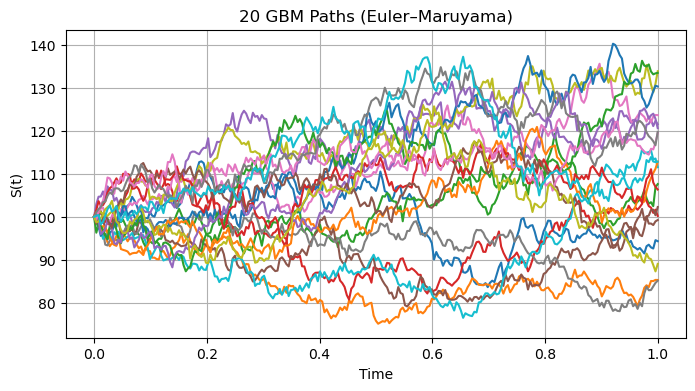

In [11]:

M = 20  # number of paths
paths = np.empty((M, N + 1))
for m in range(M):
    tgrid, Sm = euler_maruyama_gbm(S0, mu, sigma, T, N)
    paths[m] = Sm
plt.figure(figsize=(8, 4))
for m in range(M):
    plt.plot(tgrid, paths[m])
plt.xlabel('Time')
plt.ylabel('S(t)')
plt.title(f'{M} GBM Paths (Euler–Maruyama)')
plt.grid(True)
plt.show()


By using the so called **Ito's lemma** it is possible to get a closed-form solution of the geometric Brownian motion, i.e. $S_t = S_0 \exp((\mu - \tfrac{1}{2}\sigma^2)t) + \sigma W_t$. 

We can simulate the same Brownian motion increments and produce the exact solution for comparison. 


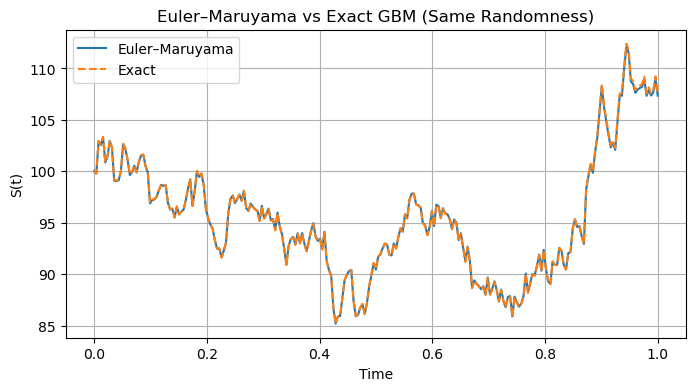

Absolute error at T: 0.224610


In [12]:
def exact_gbm(S0, mu, sigma, T, N):
    dt=T/N
    t = np.linspace(0, T, N + 1)
    Z = np.random.randn(N)
    W = np.zeros(N + 1)
    W[1:] = np.sqrt(dt) * np.cumsum(Z)
    S_exact = S0 * np.exp((mu - 0.5 * sigma**2) * t + sigma * W)
    return t, S_exact

# To compare fairly, reuse the same random numbers by controlling the RNG state.
rng_state = np.random.get_state()

t_euler, S_euler = euler_maruyama_gbm(S0, mu, sigma, T, N)

np.random.set_state(rng_state)
t_exact, S_exact = exact_gbm(S0, mu, sigma, T, N)

plt.figure(figsize=(8, 4))
plt.plot(t_euler, S_euler, label='Euler–Maruyama')
plt.plot(t_exact, S_exact, linestyle='--', label='Exact')
plt.xlabel('Time')
plt.ylabel('S(t)')
plt.title('Euler–Maruyama vs Exact GBM (Same Randomness)')
plt.legend()
plt.grid(True)
plt.show()

# Report error 
for i in range(len(t)):
    final_error = np.max(abs(S_euler[i] - S_exact[i]))
print(f"Absolute error at T: {final_error:.6f}")


# Conclusions

Euler's methods is a useful tool of stochastic numerical analysis. 

This algorithm is fundamental to understand better the Geometric Browinan motion and to explore more in details financial models.
